# 3.11. Classification

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import numpy as np



In [2]:
data = load_breast_cancer()
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [3]:
print(data.keys())
print(data.data.shape)
print(data.target.shape)
print(data.filename)
print(type(data.data))

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
(569, 30)
(569,)
breast_cancer.csv
<class 'numpy.ndarray'>


In [4]:
X_train_mnist, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.33)

In [5]:
print(X_train_mnist.shape)
N, D = X_train_mnist.shape
print(N, D)
print(y_test.shape)

(381, 30)
381 30
(188,)


In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_mnist = scaler.fit_transform (X_train_mnist)
X_test = scaler.transform(X_test)

In [7]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(D,)),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

In [8]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.03),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [9]:
r = model.fit(X_train_mnist, y_train, validation_data=(X_test, y_test), epochs=100)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.7199 - loss: 0.5333 - val_accuracy: 0.9043 - val_loss: 0.1873
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9450 - loss: 0.1527 - val_accuracy: 0.9574 - val_loss: 0.1064
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9661 - loss: 0.0969 - val_accuracy: 0.9574 - val_loss: 0.0905
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9847 - loss: 0.0782 - val_accuracy: 0.9628 - val_loss: 0.0886
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9810 - loss: 0.0751 - val_accuracy: 0.9628 - val_loss: 0.0899
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9874 - loss: 0.0626 - val_accuracy: 0.9628 - val_loss: 0.0915
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9885 - loss: 0.0698 - val_accuracy: 0.9628 - val_loss: 0.0881
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9884 - loss: 0.0623 - val_accuracy: 0.9628

KeyboardInterrupt: 

In [ ]:
print(f"Train score: {model.evaluate(X_train_mnist, y_train)}")
print(f"Test score: {model.evaluate(X_test, y_test)}")

In [ ]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label="val_loss")
plt.legend()

In [ ]:
print(type(r))
print(r.history.keys())


In [ ]:
plt.plot(r.history['accuracy'], label='train_acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

In [ ]:
p = model.predict(X_test)
print(p[:5])

In [ ]:
p = np.round(p).astype(int).flatten()
print(p[:5])
print(y_test[:5])
a = 0
for i in range(len(p)):
    if p[i] != y_test[i]:
        print(f"Error: {a} {p[i]} {y_test[i]}")
        a += 1

In [ ]:
print(np.mean(p == y_test))
model.evaluate(X_test, y_test)

In [ ]:
model.save('breast_cancer_model.h5')

!ls -lh

In [ ]:
model = tf.keras.models.load_model('breast_cancer_model.h5')
print(model.layers)

# 3.12.

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(D,)),
    tf.keras.layers.Dense(1),
])

In [ ]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
              loss='mse',
              metrics=['accuracy'])

In [ ]:
r = model.fit(X_train_mnist, y_train, validation_data=(X_test, y_test), epochs=100)

In [ ]:
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='train_loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

# 3.13 Regression notebook

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

In [ ]:
MAX_EPOCHS = 50
BATCH_SIZE = 18

In [ ]:
if not os.path.exists("moore.csv"):
    !wget https://raw.githubusercontent.com/lazyprogrammer/machine_learning_examples/master/tf2.0/moore.csv
else:
    print("Already exists")

In [ ]:
data = pd.read_csv('moore.csv', header=None).to_numpy()

In [ ]:
print(data)

In [ ]:
X = data[:, 0].reshape(-1, 1)
y = data[:, 1].reshape(-1, 1)

In [ ]:
print(X.shape, y.shape)
N, D = X.shape

In [ ]:
plt.scatter(X, y)

In [ ]:
Y = np.log(y)
X = X - X.mean()
plt.scatter(X, Y)

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(D,)),
    tf.keras.layers.Dense(1),
])

In [ ]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
              loss='mse',)

In [ ]:
def schedule(epoch, lr):
    if epoch >= MAX_EPOCHS//2:
        return lr - (0.0009/(MAX_EPOCHS/2))*(BATCH_SIZE/N)
    return lr
scheduler = tf.keras.callbacks.LearningRateScheduler(schedule)

In [ ]:
r = model.fit(X, Y, epochs=MAX_EPOCHS, callbacks=[scheduler], batch_size=BATCH_SIZE)

In [ ]:
plt.plot(r.history['loss'], label='train_loss')
plt.yscale('log')
plt.show()

In [ ]:
a = model.layers[0].get_weights()[0][0][0]
print(a)

# 3.16. Making predictions

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
print(X.shape)
print(Y.shape)

In [ ]:
p = model.predict(X)
p = p.flatten()
print(Y[:5])
print(p[:5])

In [ ]:
Y_hat = p.reshape(-1)
#y_hat = y.flatten()
print(Y_hat[:5])

In [ ]:
plt.scatter(X, Y)
plt.plot(X, Y_hat)

In [ ]:
w, b = model.layers[0].get_weights()
print(w, b)

X = X.reshape(-1, 1)

Y_hat2 = X.dot(w) + b
Y_hat2 = Y_hat2.flatten()

np.allclose(Y_hat, Y_hat2)

# 4.26 ANN

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
(X_train_mnist, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
print(type(X_train_mnist))
print(len(X_train_mnist))
print(X_train_mnist.shape)

In [ ]:
X_train_mnist = X_train_mnist.reshape(-1, X_train_mnist.shape[1]*X_train_mnist.shape[2])
X_train_mnist = X_train_mnist.astype(np.float32) / 255.0
print(X_train_mnist.shape)

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(X_train_mnist.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.15),
    tf.keras.layers.Dense(10, activation='softmax'),
])

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall'])

# 4.27 ANN For Image Classification

In [ ]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print(tf.test.is_built_with_cuda())
print(tf.config.list_physical_devices('GPU'))
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

In [ ]:
mnist = tf.keras.datasets.mnist
print(type(mnist))
print(mnist)

In [ ]:
(X_train_mnist, y_train), (X_test, y_test) = mnist.load_data()
print(X_train_mnist.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(X_train_mnist.shape[1], X_train_mnist.shape[2])),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.18),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'],
)

In [ ]:
r = model.fit(X_train_mnist, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=518)

In [ ]:
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='train_loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

In [ ]:
plt.plot(r.history['accuracy'], label=['train_acc'])
plt.plot(r.history['val_accuracy'], label=['val_acc'])
plt.legend()

In [ ]:
print(model.evaluate(X_test, y_test))

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import itertools

In [ ]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    else:
        print('no normalization')
    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment='center', color='white' if cm[i, j] > thresh else 'black')
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [ ]:
p_test = model.predict(X_test)
cm = confusion_matrix(y_test, np.argmax(p_test, axis=1))
plot_confusion_matrix(cm, list(range(10)))

In [ ]:
misclassified_idx = np.where(np.argmax(p_test, axis=1) != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(X_test[i], cmap='gray')
plt.title(f"True label: {y_test[i]}, Prediction: {np.argmax(p_test[i])}")
plt.show()

# TEST GPU VS CPU

In [ ]:
import tensorflow as tf
import numpy as np
import time

# Fix randomness for fairness
tf.random.set_seed(42)
np.random.seed(42)

# Create synthetic dataset
N = 200_000
D = 512

x = np.random.rand(N, D).astype(np.float32)
y = np.random.rand(N, 1).astype(np.float32)

def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(1024, activation='relu'),
        tf.keras.layers.Dense(1024, activation='relu'),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def benchmark(device_name):
    with tf.device(device_name):
        model = build_model()

        # Warm-up (important for fair comparison)
        model.fit(x[:5000], y[:5000], epochs=1, batch_size=2048, verbose=0)

        start = time.perf_counter()
        model.fit(x, y, epochs=3, batch_size=2048, verbose=0)
        end = time.perf_counter()

    return end - start

cpu_time = benchmark('/CPU:0')
gpu_time = benchmark('/GPU:0')

print(f"CPU time: {cpu_time:.2f} sec")
print(f"GPU time: {gpu_time:.2f} sec")
print(f"Speedup: {cpu_time / gpu_time:.2f}x")

# 4.28 ANN For Regression

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
N = 1000
X = np.random.random((N, 2)) * 20 - 10
Y = np.cos(2*X[:, 0]) + np.cos(3*X[:, 1])

norm = tf.keras.layers.Normalization()
norm.adapt(X)


In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection= '3d')
ax.scatter(X[:, 0], X[:, 1], Y)
plt.show()

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    norm,
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3e-3, amsgrad=True), loss='mse')
r = model.fit(X, Y, epochs=500, batch_size=64)

In [ ]:
plot = plt.figure()
plt.plot(r.history['loss'], label='training_loss')
plt.legend()

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], Y)
line = np.linspace(-3, 3, 50)
xx, yy = np.meshgrid(line, line)
Xgrid = np.vstack((xx.flatten(), yy.flatten())).T
Yhat = model.predict(Xgrid).flatten()
ax.plot_trisurf(Xgrid[:, 0], Xgrid[:, 1], Yhat, linewidth=0.2, antialiased=True)
plt.show()

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], Y)
line = np.linspace(-10, 10, 50)
xx, yy = np.meshgrid(line, line)
Xgrid = np.vstack((xx.flatten(), yy.flatten())).T
Yhat = model.predict(Xgrid).flatten()
ax.plot_trisurf(Xgrid[:, 0], Xgrid[:, 1], Yhat, linewidth=0.2, antialiased=True)
plt.show()

# 5.35 CNN Code Preparation

In [10]:
!pip install tensorflow
!pip install matplotlib
!pip install scikit-learn
!pip install numpy
!pip install scipy

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np

In [4]:
from tensorflow.keras.layers import Input, Conv2D, Dropout, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model

In [5]:
def create_model(input_shape, output_classes):    
    i = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Conv2D(16, kernel_size=3, strides=1, activation='relu')(i)
    x = tf.keras.layers.MaxPooling2D(pool_size=2)(x)
    x = tf.keras.layers.Conv2D(32, kernel_size=3, strides=1, activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=2)(x)
    x = tf.keras.layers.Conv2D(64, kernel_size=3, strides=1, activation='relu')(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(output_classes, activation='softmax')(x)
    
    model = tf.keras.Model(inputs=i, outputs=x)
    return model

In [6]:
mnist = tf.keras.datasets.fashion_mnist.load_data()
cifar10 = tf.keras.datasets.cifar10.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


In [7]:
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist
print(X_train_mnist.shape)

(60000, 28, 28)


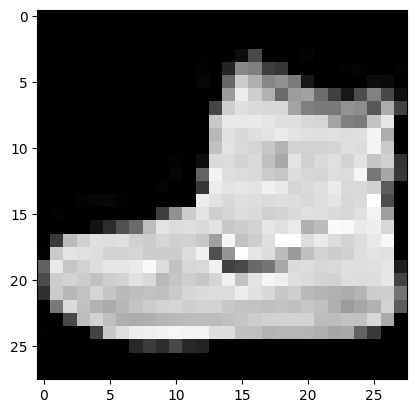

In [8]:
plot = plt.figure()
plt.imshow(X_train_mnist[0], cmap='gray')

In [9]:
X_train_mnist = X_train_mnist.reshape(X_train_mnist.shape[0], X_train_mnist.shape[1], X_train_mnist.shape[2], 1)
print(X_train_mnist.shape)
print(y_train_mnist.shape)

(60000, 28, 28, 1)
(60000,)


In [10]:
X_train_mnist, X_test_mnist = X_train_mnist.astype('float32') / 255.0, X_test_mnist.astype('float32') / 255.0
(X_train_mnist, X_val_mnist, y_train_mnist, y_val_mnist) = train_test_split(X_train_mnist, y_train_mnist, test_size=0.1, random_state=42)

In [11]:
model = create_model(input_shape=X_train_mnist[0].shape, output_classes=len(set(y_train_mnist)))

In [12]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
r = model.fit(X_train_mnist, y_train_mnist, validation_data=(X_val_mnist, y_val_mnist), epochs=10, batch_size=128)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7174 - loss: 0.7520 - val_accuracy: 0.8605 - val_loss: 0.3755
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8505 - loss: 0.4020 - val_accuracy: 0.8768 - val_loss: 0.3453
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8601 - loss: 0.3743 - val_accuracy: 0.8717 - val_loss: 0.3513
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8659 - loss: 0.3629 - val_accuracy: 0.8755 - val_loss: 0.3309
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8671 - loss: 0.3543 - val_accuracy: 0.8763 - val_loss: 0.3322
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8670 - loss: 0.3559 - val_accuracy: 0.8558 - val_loss: 0.3766
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8709 - loss: 0.3493 - val_accuracy: 0.8710 - val_loss: 0.3318
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8740 - loss: 0.3428 - val_accuracy: 

In [13]:
p_test = np.argmax(model.predict(X_test_mnist), axis=1)
print(p_test.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
(10000,)


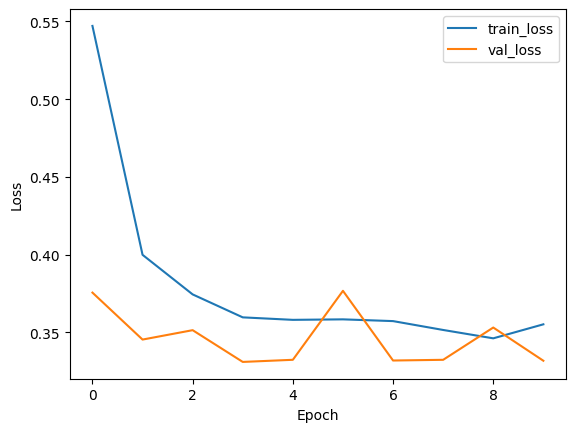

In [14]:
plt.plot(r.history['loss'], label='train_loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

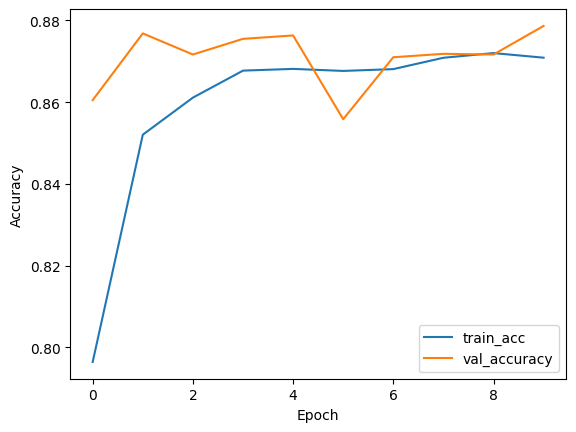

In [15]:
plt.plot(r.history['accuracy'], label='train_acc')
plt.plot(r.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [16]:
labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [17]:
idx_errors = np.where(p_test != y_test_mnist)[0]
print(idx_errors.shape)

(1278,)


Text(0.5, 1.0, 'True label: Pullover, prediction: Shirt')

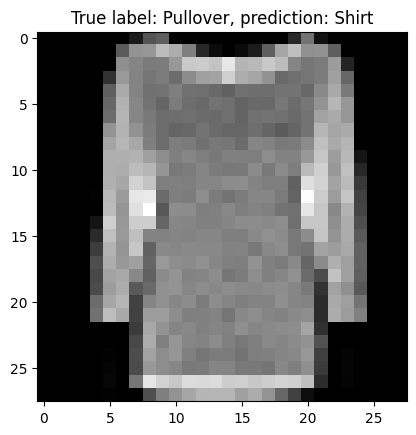

In [18]:
i = np.random.choice(idx_errors)
plt.imshow(X_test_mnist[i], cmap='gray')
plt.title(f"True label: {labels[y_test_mnist[i]]}, prediction: {labels[p_test[i]]}")

[[852   3  10  26   3   0 100   0   6   0]
 [  3 979   1  12   4   0   0   0   1   0]
 [ 20   2 685  13 142   0 136   0   2   0]
 [ 18   9  12 897  24   0  37   0   3   0]
 [  1   1  57  35 831   0  73   0   2   0]
 [  0   0   0   1   0 957   0  28   0  14]
 [175   3  53  29  87   0 641   0  12   0]
 [  0   0   0   0   0  15   0 945   0  40]
 [  0   0   2   4   3   3  10   4 974   0]
 [  0   0   0   0   0   4   0  35   0 961]]


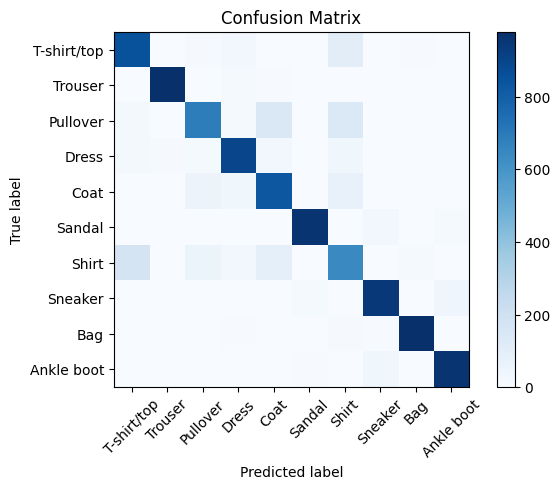

In [19]:
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(cm, classes):
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

cm = confusion_matrix(y_test_mnist, p_test)
print(cm)
plot_confusion_matrix(cm, classes=labels)

# 5.37 CNN for CIFAR10

In [20]:
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10
print(X_train_cifar.shape)
print(y_train_cifar.shape)

(50000, 32, 32, 3)
(50000, 1)


In [21]:
y_train_cifar = y_train_cifar.reshape(-1)
y_test_cifar = y_test_cifar.reshape(-1)
print(y_train_cifar.shape)

(50000,)


In [22]:
X_train_cifar, X_test_cifar = X_train_cifar.astype('float32') / 255.0, X_test_cifar.astype('float32') / 255.0
(X_train_cifar, X_val_cifar, y_train_cifar, y_val_cifar) = train_test_split(X_train_cifar, y_train_cifar, test_size=0.1, random_state=42)

np.uint8(3)

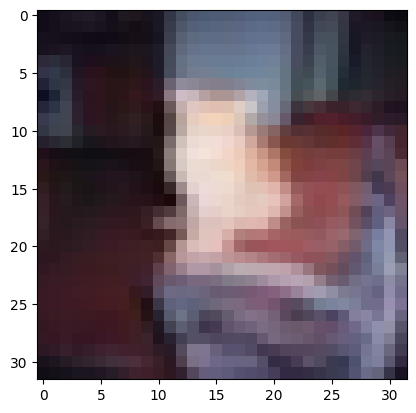

In [23]:
plt.imshow(X_train_cifar[0])
y_train_cifar[0]

In [24]:
print(X_train_cifar.shape)
print(y_train_cifar.shape, y_test_cifar.shape)
K = len(set(y_train_cifar))
print(X_train_cifar[0])

(45000, 32, 32, 3)
(45000,) (10000,)
[[[0.07058824 0.04705882 0.09411765]
  [0.08627451 0.0627451  0.10980392]
  [0.10588235 0.08235294 0.12941177]
  ...
  [0.10196079 0.07450981 0.11764706]
  [0.05490196 0.04313726 0.07058824]
  [0.04313726 0.03921569 0.0627451 ]]

 [[0.07058824 0.04705882 0.09411765]
  [0.08235294 0.05882353 0.10588235]
  [0.09803922 0.07450981 0.12156863]
  ...
  [0.10588235 0.09019608 0.1254902 ]
  [0.08235294 0.08235294 0.10588235]
  [0.06666667 0.07058824 0.09411765]]

 [[0.09019608 0.06666667 0.11372549]
  [0.08627451 0.0627451  0.10980392]
  [0.07843138 0.05490196 0.10196079]
  ...
  [0.11372549 0.10980392 0.14509805]
  [0.09803922 0.10196079 0.1254902 ]
  [0.08235294 0.09803922 0.11764706]]

 ...

 [[0.17254902 0.09411765 0.13725491]
  [0.1882353  0.10196079 0.14901961]
  [0.21568628 0.12156863 0.16862746]
  ...
  [0.50980395 0.5137255  0.62352943]
  [0.4117647  0.40784314 0.49803922]
  [0.25490198 0.23529412 0.32156864]]

 [[0.09803922 0.06666667 0.10588235]


In [25]:
model = create_model(input_shape=X_train_cifar[0].shape, output_classes=K)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'],
              )
r = model.fit(X_train_cifar, y_train_cifar, validation_data=(X_val_cifar, y_val_cifar), epochs=10, batch_size=64)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.3369 - loss: 1.7999 - val_accuracy: 0.5038 - val_loss: 1.3976
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5394 - loss: 1.2929 - val_accuracy: 0.5574 - val_loss: 1.2507
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6015 - loss: 1.1326 - val_accuracy: 0.6294 - val_loss: 1.0443
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6368 - loss: 1.0365 - val_accuracy: 0.6554 - val_loss: 0.9693
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6703 - loss: 0.9432 - val_accuracy: 0.6418 - val_loss: 1.0161
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6924 - loss: 0.8791 - val_accuracy: 0.6876 - val_loss: 0.8978
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7167 - loss: 0.8137 - val_accuracy: 0.6990 - val_loss: 0.8581
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7356 - loss: 0.7564 - val_accuracy: 0

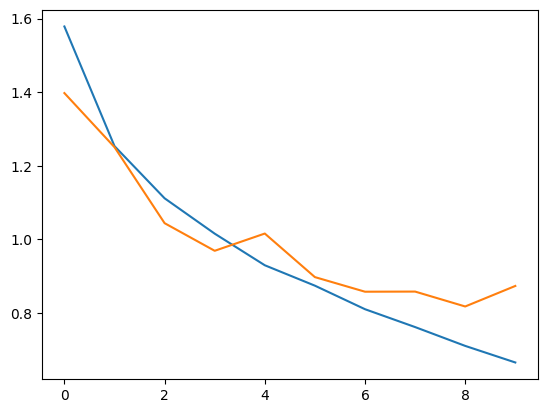

In [26]:
plt.plot(r.history['loss'], label='train_loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.show()

# 5.38 Data Augmentation

In [32]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [33]:
batch_size = 64

data_generator = ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True)

train_generator = data_generator.flow(X_train_cifar, y_train_cifar, batch_size=batch_size)
val_generator = data_generator.flow(X_val_cifar, y_val_cifar, batch_size=256)

steps_per_epoch = X_train_cifar.shape[0] // batch_size

In [34]:
model = create_model(input_shape=X_train_cifar[0].shape, output_classes=K)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'],
              )


In [35]:
r = model.fit(train_generator, validation_data=val_generator, steps_per_epoch=steps_per_epoch, epochs=10)

Epoch 1/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.3205 - loss: 1.8352 - val_accuracy: 0.5080 - val_loss: 1.3684
Epoch 2/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4531 - loss: 1.4043 - val_accuracy: 0.4978 - val_loss: 1.3995
Epoch 3/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.5082 - loss: 1.3648 - val_accuracy: 0.5574 - val_loss: 1.2164
Epoch 4/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5938 - loss: 1.0033 - val_accuracy: 0.5560 - val_loss: 1.2089
Epoch 5/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.5592 - loss: 1.2391 - val_accuracy: 0.5926 - val_loss: 1.1182
Epoch 6/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5625 - loss: 1.1409 - val_accuracy: 0.5998 - val_loss: 1.1090
Epoch 7/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.5926 - loss: 1.1547 - val_accuracy: 0.6038 - val_loss: 1.1236
Epoch 8/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4844 - loss: 1.2834 - val_accu

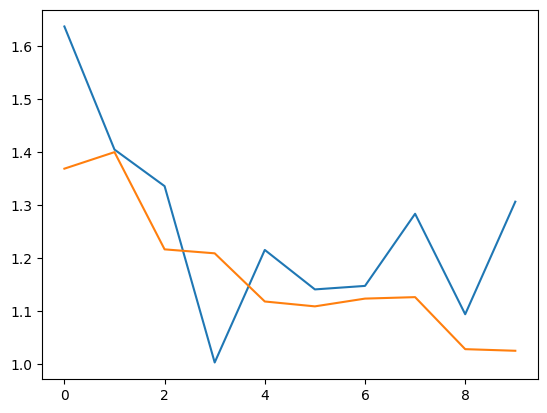

In [36]:
plt.plot(r.history['loss'], label='train_loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.show()

# 5.40 Improving CIFAR-10

In [3]:
!pip install tensorflow
!pip install matplotlib
!pip install scikit-learn
!pip install numpy

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   -------------------------- ------------- 1.6/2.3 MB 9.5 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 10.4 MB/s  0:00:00
Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl (7.0 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---

In [4]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, Dropout, MaxPooling2D, GlobalMaxPooling2D, Flatten, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
import os

print(len(tf.config.list_physical_devices('GPU')))

0


In [5]:
data = cifar10.load_data()
print(type(data))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
<class 'tuple'>


c:\Users\lbistas\projects\cnn_testing\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [6]:
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = data
print(X_train_cifar.shape)
print(y_train_cifar.shape)

(50000, 32, 32, 3)
(50000, 1)


In [7]:
X_train_cifar, X_test_cifar = X_train_cifar.astype('float32') / 255.0, X_test_cifar.astype('float32') / 255.0
y_train_cifar = y_train_cifar.flatten()
y_test_cifar = y_test_cifar.flatten()

In [8]:
print(X_train_cifar.shape)
print(y_train_cifar.shape)

(50000, 32, 32, 3)
(50000,)


In [9]:
(X_train_cifar, X_val_cifar, y_train_cifar, y_val_cifar) = train_test_split(X_train_cifar, y_train_cifar, test_size=0.1, random_state=42)
print(X_train_cifar.shape)
print(y_train_cifar.shape)
print(X_val_cifar.shape)
print(y_val_cifar.shape)

(45000, 32, 32, 3)
(45000,)
(5000, 32, 32, 3)
(5000,)


In [10]:
batch_size = 128

data_generator = ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True)
train_generator = data_generator.flow(X_train_cifar, y_train_cifar, batch_size=batch_size)

In [ ]:
def create_model(input_shape, output_classes):
    
    i = Input(shape=input_shape)

    x = Conv2D(16, kernel_size=3, strides=1, padding='valid', activation='leaky_relu')(i)
    x = BatchNormalization()(x)
    
    x = Conv2D(16, kernel_size=3, strides=1, padding='valid', activation='leaky_relu')(x)
    x = BatchNormalization()(x)
    #x = MaxPooling2D(pool_size=2)(x)
    
    x = Conv2D(32, kernel_size=3, strides=1, padding='valid', activation='leaky_relu')(x)
    x = BatchNormalization()(x)
    
    x = Conv2D(32, kernel_size=3, strides=1, padding='same', activation='leaky_relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=2)(x)
    
    x = Conv2D(64, kernel_size=3, strides=1, padding='valid', activation='leaky_relu')(x)
    x = BatchNormalization()(x)
    
    x = Conv2D(64, kernel_size=3, strides=1, padding='valid', activation='leaky_relu')(x)
    x = BatchNormalization()(x)    
    #x = MaxPooling2D(pool_size=2)(x)
    
    x = Conv2D(128, kernel_size=3, strides=1, padding='valid', activation='leaky_relu')(x)
    x = BatchNormalization()(x)
    
    x = Conv2D(128, kernel_size=3, strides=1, padding='same', activation='leaky_relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=2, padding="same")(x)

    #x = GlobalMaxPooling2D()(x)
    #x = Dropout(0.15)(x)

    x = Flatten()(x)
    x = Dropout(0.15)(x)
    
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.15)(x)
    
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.15)(x)
    
    x = Dense(output_classes, activation='softmax')(x)

    model = Model(inputs=i, outputs=x)

    return model

In [12]:
input_shape = X_train_cifar[0].shape
output_classes = len(set(y_train_cifar))

model = create_model(input_shape, output_classes)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [13]:
steps_per_epoch = X_train_cifar.shape[0] // batch_size

r = model.fit(train_generator, validation_data=(X_val_cifar, y_val_cifar), epochs=15)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 36s 92ms/step - accuracy: 0.3933 - loss: 1.6751 - val_accuracy: 0.2542 - val_loss: 2.3394
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 85ms/step - accuracy: 0.5350 - loss: 1.3066 - val_accuracy: 0.5504 - val_loss: 1.2911
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 84ms/step - accuracy: 0.6054 - loss: 1.1276 - val_accuracy: 0.6378 - val_loss: 1.0501
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 31s 89ms/step - accuracy: 0.6432 - loss: 1.0249 - val_accuracy: 0.6774 - val_loss: 0.9357
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - accuracy: 0.6720 - loss: 0.9459 - val_accuracy: 0.6978 - val_loss: 0.8721
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - accuracy: 0.6963 - loss: 0.8814 - val_accuracy: 0.7088 - val_loss: 0.8517
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 32s 90ms/step - accuracy: 0.7116 - loss: 0.8350 - val_accuracy: 0.6844 - val_loss: 0.9389
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 33s 95ms/step - accuracy: 0.7269 - loss: 0.7937 - 

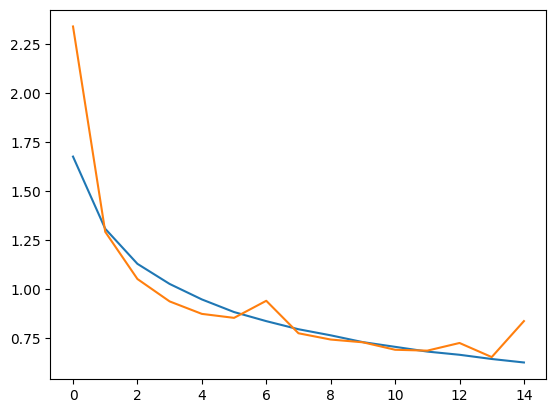

In [14]:
import matplotlib.pyplot as plt

plt.plot(r.history['loss'], label='train_loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.show()

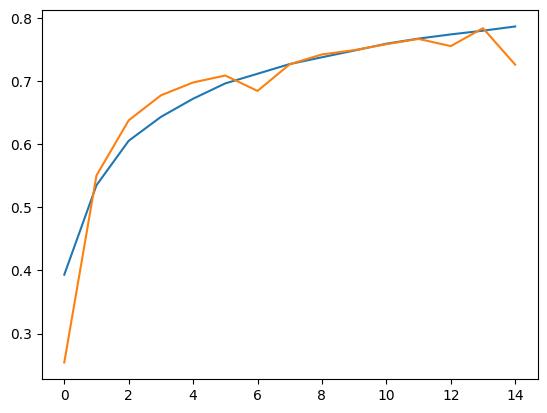

In [15]:
plt.plot(r.history['accuracy'], label='train_acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.show()

In [16]:
import numpy as np

pred = model.predict(X_test_cifar)
pred = np.argmax(pred, axis=1)
model.evaluate(X_test_cifar, y_test_cifar)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7298 - loss: 0.8439


[0.8439390659332275, 0.7297999858856201]

In [17]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 9, 9, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 9, 9, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1152)           │             

 Total params: 2,856,272 (10.90 MB)

 Trainable params: 951,770 (3.63 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 1,903,542 (7.26 MB)

# 6.43 Text Preprocessing

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

In [47]:
sentences = [
    "I love machine learning",
    "Deep learning is great",
    "Natural language processing is fascinating",
    "I enjoy coding in Python",]

In [48]:
MAX_VOCAB_SIZE = 10_000

In [49]:
vectorization_layer = TextVectorization(max_tokens=MAX_VOCAB_SIZE)

In [50]:
vectorization_layer.adapt(sentences)

In [51]:
sequences = vectorization_layer(sentences)
print(sequences)

tf.Tensor(
[[ 4  9  8  2  0]
 [15  2  3 12  0]
 [ 7 10  6  3 13]
 [ 4 14 16 11  5]], shape=(4, 5), dtype=int64)


In [52]:
vectorization_layer.get_vocabulary()

['',
 '[UNK]',
 np.str_('learning'),
 np.str_('is'),
 np.str_('i'),
 np.str_('python'),
 np.str_('processing'),
 np.str_('natural'),
 np.str_('machine'),
 np.str_('love'),
 np.str_('language'),
 np.str_('in'),
 np.str_('great'),
 np.str_('fascinating'),
 np.str_('enjoy'),
 np.str_('deep'),
 np.str_('coding')]

In [53]:
word2idx = {v: k for k, v in enumerate(vectorization_layer.get_vocabulary())}
print(word2idx)

{'': 0, '[UNK]': 1, np.str_('learning'): 2, np.str_('is'): 3, np.str_('i'): 4, np.str_('python'): 5, np.str_('processing'): 6, np.str_('natural'): 7, np.str_('machine'): 8, np.str_('love'): 9, np.str_('language'): 10, np.str_('in'): 11, np.str_('great'): 12, np.str_('fascinating'): 13, np.str_('enjoy'): 14, np.str_('deep'): 15, np.str_('coding'): 16}


In [58]:
vectorization_layer_truncated = TextVectorization(max_tokens=MAX_VOCAB_SIZE, output_sequence_length=30)

vectorization_layer_truncated.adapt(sentences)
sequences_truncated = vectorization_layer_truncated(sentences)
print(sequences_truncated)

tf.Tensor(
[[ 4  9  8  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0]
 [15  2  3 12  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0]
 [ 7 10  6  3 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0]
 [ 4 14 16 11  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0]], shape=(4, 30), dtype=int64)


In [59]:
vectorization_layer_truncated.get_vocabulary()

['',
 '[UNK]',
 np.str_('learning'),
 np.str_('is'),
 np.str_('i'),
 np.str_('python'),
 np.str_('processing'),
 np.str_('natural'),
 np.str_('machine'),
 np.str_('love'),
 np.str_('language'),
 np.str_('in'),
 np.str_('great'),
 np.str_('fascinating'),
 np.str_('enjoy'),
 np.str_('deep'),
 np.str_('coding')]

In [60]:
idx2word_truncated = {k: v for k, v in enumerate(vectorization_layer_truncated.get_vocabulary())}
print(idx2word_truncated)

{0: '', 1: '[UNK]', 2: np.str_('learning'), 3: np.str_('is'), 4: np.str_('i'), 5: np.str_('python'), 6: np.str_('processing'), 7: np.str_('natural'), 8: np.str_('machine'), 9: np.str_('love'), 10: np.str_('language'), 11: np.str_('in'), 12: np.str_('great'), 13: np.str_('fascinating'), 14: np.str_('enjoy'), 15: np.str_('deep'), 16: np.str_('coding')}


In [61]:
for seq in sequences_truncated:
    print([str(idx2word_truncated[int(idx)]) for idx in seq])


['i', 'love', 'machine', 'learning', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']
['deep', 'learning', 'is', 'great', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']
['natural', 'language', 'processing', 'is', 'fascinating', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']
['i', 'enjoy', 'coding', 'in', 'python', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']
